In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

In [2]:
#Setup 
coords = {'AlexandriaAirport': {'lat' : 45.86801, 'lon' : -95.39399},
               'MorrisWROC': {'lat' : 45.5901, 'lon' : -95.8745},
               'OrwellDam': {'lat' : 46.2154, 'lon' : -96.178},
               'Ottertail': {'lat' : 46.4145, 'lon' : -95.5464},
               'FargoAirport': {'lat' : 46.92424, 'lon' : -96.81186},
               'GrandForksAirport': {'lat' : 47.94281, 'lon' : -97.18294},
               'Jamestown': {'lat' : 46.92586, 'lon' : -98.67037},
               'Faribault': {'lat' : 44.3092, 'lon' : -93.266},
               'Farmington': {'lat' : 44.666, 'lon' : -93.17559},
               'RedWingDam': {'lat' : 44.60981, 'lon' : -92.6098},
               'Zumbrota': {'lat' : 44.29982, 'lon' : -92.66544},
               'CrookstonExpSt' : {'lat' : 47.8186, 'lon' : -96.6139},
               'Manhomen' : {'lat' : 47.3169, 'lon' : -95.9691},
               'RedLakeFalls' : {'lat' : 47.87945, 'lon' : -96.28446},
               'Chanhassen' : {'lat' : 44.8496, 'lon' : -93.5644},
               'Delano' : {'lat' : 45.04698, 'lon' : -93.77717},
               'Gaylord' : {'lat' : 44.55647, 'lon' : -94.22077},
               'Jordan' : {'lat' : 44.6501, 'lon' : -93.6356}, 
               'BismarkAirport' : {'lat': 46.775443, 'lon': -100.755427}}

#site data
site_path = './data/climate data/' 
site_files = glob(site_path + "*/*.csv", recursive = True)

#locations for vineyards
coords_sites = {'ASH' : {'lat': 46.050133, 'lon': -95.87849}, 
                'BIS' : {'lat': 46.9713, 'lon': -100.7101},
                'BUF' : {'lat': 46.902652, 'lon': -97.495103},
                'FER' : {'lat': 47.56561, 'lon': -96.13596}, 
                'HRC' : {'lat': 44.867585, 'lon': -93.635}, 
                'SMI' : {'lat': 44.41897, 'lon': -92.942041}}

#random
state = 36

In [18]:
#clean and concat
site_data = pd.DataFrame()

for file in site_files:
  site = file.split('\\')[1]

  climateSite = file.split('_')[-1].replace('.csv', '')
  A1 = pd.read_csv(file, na_values = ['T', 'M', 'S'])
    
  A1_expanded = A1.drop(columns = [col for col in A1.columns if col.startswith('Snow')])
  A1_expanded = A1_expanded.rename(columns = {'Date':'date',
                                              'Maximum Temperature degrees (F)':'tempMax_F',
                                              'TMAX':'tempMax_F',
                                              'Minimum Temperature degrees (F)':'tempMin_F',
                                              'TMIN':'tempMin_F',
                                              'Precipitation (inches)':'precip_in',
                                              'PRCP':'precip_in'})
  A1_expanded = A1_expanded[(A1_expanded.date > '2019-01-01') & (A1_expanded.date < '2020-01-01')]
  A1_expanded['site'] = site
  A1_expanded['climateSite'] = climateSite
  A1_expanded['lat'] = coords[climateSite]['lat']
  A1_expanded['lon'] = coords[climateSite]['lon']
  #convert dates to POSIX
  A1_expanded['date'] = pd.to_datetime(A1_expanded.date)
    
  #concat
  site_data = pd.concat([site_data, A1_expanded])

site_data = site_data.drop(columns = ['STATION', 'TAVG']).reset_index(drop = True)

In [40]:
#setup for interpolation
#convert timestamp to numeric - days since 2019-01-01
site_data["doy"] = (site_data.date - pd.Timestamp("2018-12-31")).dt.total_seconds()/(24*3600)

#gap fill using KNN for temp and (maybe go back and check to set 0s for precip)
imputer = KNNImputer(n_neighbors = 5)
site_data_filled = site_data
site_data_filled[['lat', 'lon', 'doy', 'tempMax_F', 'tempMin_F', 'precip_in']] = imputer.fit_transform(
    site_data_filled[['lat', 'lon', 'doy', 'tempMax_F', 'tempMin_F', 'precip_in']])

#set targets
X = site_data_filled[['lat', 'lon', 'doy']].values
Y_tempMax = site_data_filled['tempMax_F'].values
Y_tempMin = site_data_filled['tempMin_F'].values
Y_precip = site_data_filled['precip_in'].values

#for precip only - transform target to cumulative precip
Y_precip_cumsum = site_data_filled.groupby('climateSite')['precip_in'].cumsum().values


Run below for different Y variables

- change the Y in the train test split
- modify figure labels in time series plot
- modify export name in time series plot

In [41]:
#train test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_precip_cumsum, test_size = 0.2, random_state = state
)

In [42]:
#alternate kernel
spatio_temporal_kernel = RBF(length_scale=[1, 1, 1], length_scale_bounds=[(1e-5, 1e5), (1e-5, 1e5), (1e-5, 1e5)])

# Initialize GP regressor
gpr = GaussianProcessRegressor(
    kernel=spatio_temporal_kernel,
    n_restarts_optimizer = 10,
    random_state=state)

In [43]:
# Fit to training data
gpr.fit(X_train, Y_train)
 
# Print optimized kernel
print("Optimized kernel:", gpr.kernel_)

Optimized kernel: RBF(length_scale=[0.448, 0.588, 1.53])


In [61]:
# Predict mean and standard deviation (uncertainty)
Y_pred, Y_std = gpr.predict(X_test, return_std=True)

rmse = root_mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
 
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.5f}")

RMSE: 0.94
MAE: 0.41
R²: 0.99610


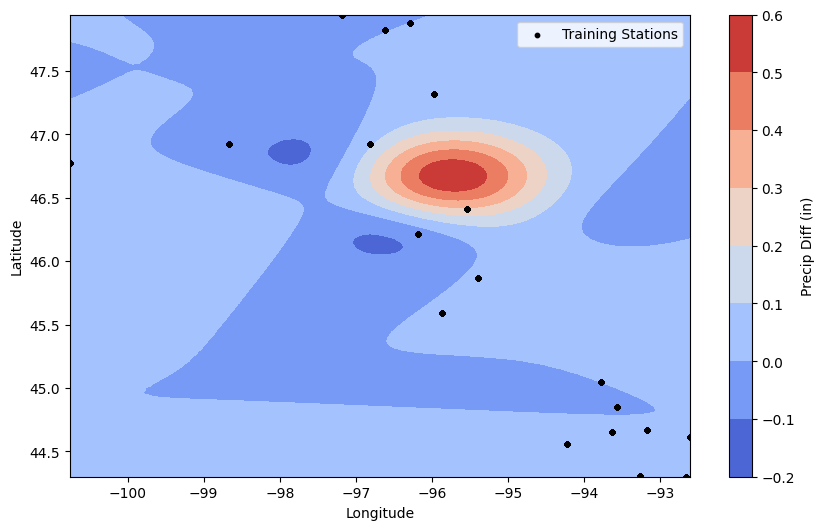

In [62]:
# Define a grid of lat/lon points for the target time (e.g., time=0.5 days since 2023-01-01)
lat_grid = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
lon_grid = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 100)
lat_mesh, lon_mesh = np.meshgrid(lat_grid, lon_grid)
 
# Create input grid: [lat, lon, fixed_time]
fixed_time = 6.5  # Example time
X_grid = np.stack([lat_mesh.ravel(), lon_mesh.ravel(), np.full_like(lat_mesh.ravel(), fixed_time)], axis=1)
 
# Predict temperatures on the grid
y_pred_grid, y_std_grid = gpr.predict(X_grid, return_std=True)
y_pred_grid = y_pred_grid.reshape(lat_mesh.shape)
y_std_grid = y_std_grid.reshape(lat_mesh.shape)
 
# Plot predicted temperature
plt.figure(figsize=(10, 6))
plt.contourf(lon_grid, lat_grid, y_pred_grid, cmap="coolwarm")
plt.colorbar(label="Precip Diff (in)")
plt.scatter(X_train[:, 1], X_train[:, 0], c="black", s=10, label="Training Stations")
#plt.title(f"Predicted Temperature at t={fixed_time} days")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_18644\1394212874.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor = (1,1), frameon = False)


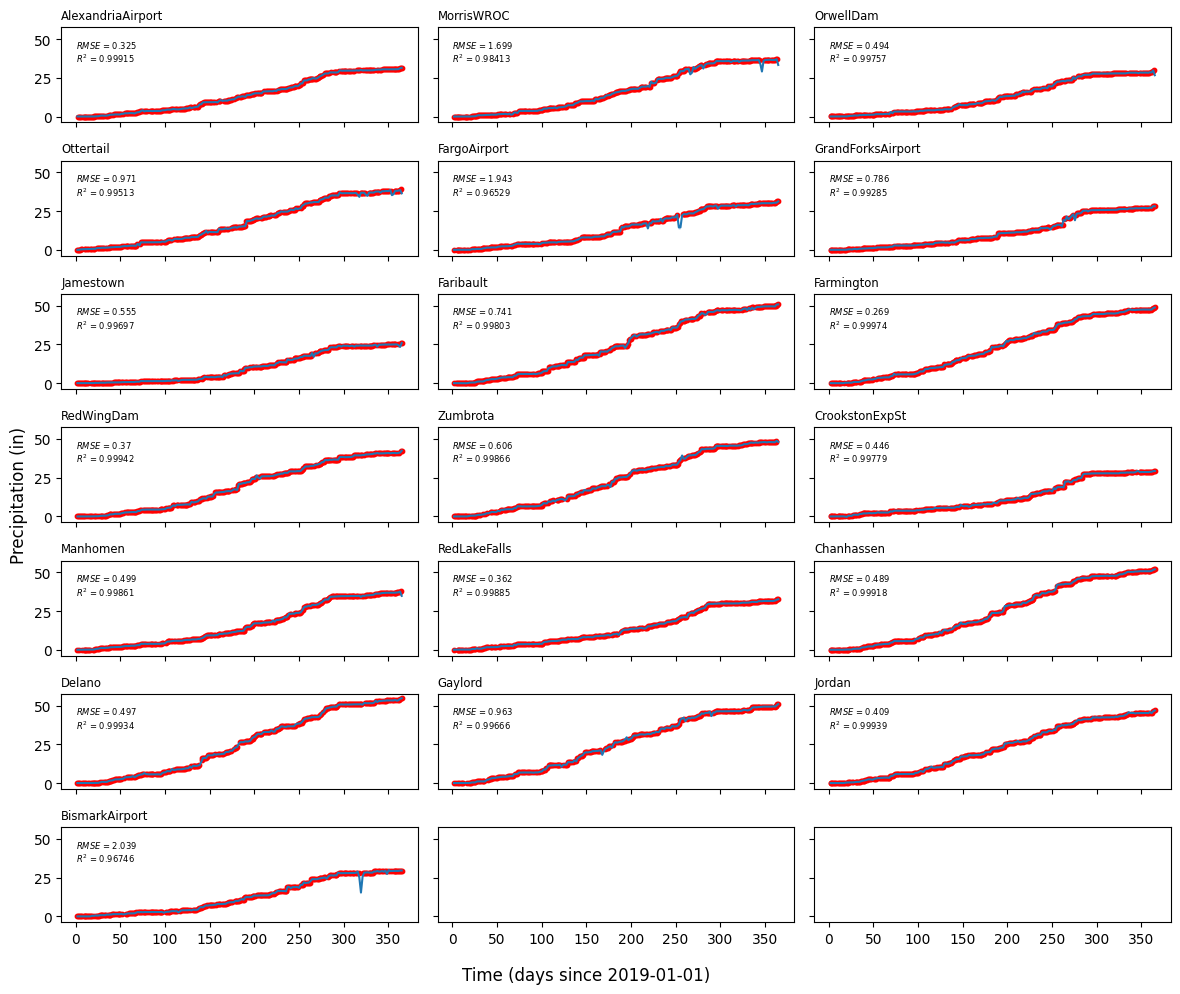

In [66]:
# Define time grid for the fixed location
time_grid = np.linspace(X_train[:, 2].min(), X_train[:, 2].max(), 200)

#cycle through sites to plot timeseries along with RMSE and R2
fig, ax = plt.subplots(7, 3, figsize=(12, 10), 
                       sharex = True, sharey = True, 
                       layout = 'tight')
axs = ax.ravel()
i = 0

for site in coords.keys():
    fixed_lat = coords[site]['lat']
    fixed_lon = coords[site]['lon']
    
    # Create input grid: [fixed_lat, fixed_lon, time]
    X_time_grid = np.stack([np.full_like(time_grid, fixed_lat), np.full_like(time_grid, fixed_lon), time_grid], axis=1)
    
    # Predict temperatures over time
    y_pred_time, y_std_time = gpr.predict(X_time_grid, return_std=True)

    #metrics
    X_site_grid = np.stack([np.full_like(X_test[X_test[:, 0]==fixed_lat, 2], fixed_lat), np.full_like(X_test[X_test[:, 0]==fixed_lat, 2], fixed_lon), X_test[X_test[:, 0]==fixed_lat, 2]], axis=1)
    Y_pred_site, Y_std_site = gpr.predict(X_site_grid, return_std=True)
    rmse = root_mean_squared_error(Y_test[X_test[:, 0]==fixed_lat], Y_pred_site)
    r2 = r2_score(Y_test[X_test[:, 0]==fixed_lat], Y_pred_site)
    
    axs[i].plot(time_grid, y_pred_time, label="Predicted Precip")
    axs[i].fill_between(time_grid, y_pred_time - 1.96*y_std_time, y_pred_time + 1.96*y_std_time, alpha=0.2, label="95% CI")
    axs[i].scatter(X_train[X_train[:, 0]==fixed_lat, 2], Y_train[X_train[:, 0]==fixed_lat], c="red", s=10, label="Observed Data")
    axs[i].set_title(site, size = 'small', loc = 'left')

    #text anotation
    axs[i].text(0, 35, r'$RMSE$ = ' + str(round(rmse, 3)) + '\n' +  r'$R^2$ = ' + str(round(r2, 5)), 
                size = 6)
    i = i+1

fig.supxlabel("Time (days since 2019-01-01)")
fig.supylabel("Precipitation (in)")
plt.legend(bbox_to_anchor = (1,1), frameon = False)
plt.savefig('./figures/climate interpolation/precipitation_sites.pdf', bbox_inches = 'tight')
plt.savefig('./figures/climate interpolation/precipitation_sites.png', dpi = 300, bbox_inches = 'tight')
plt.show()

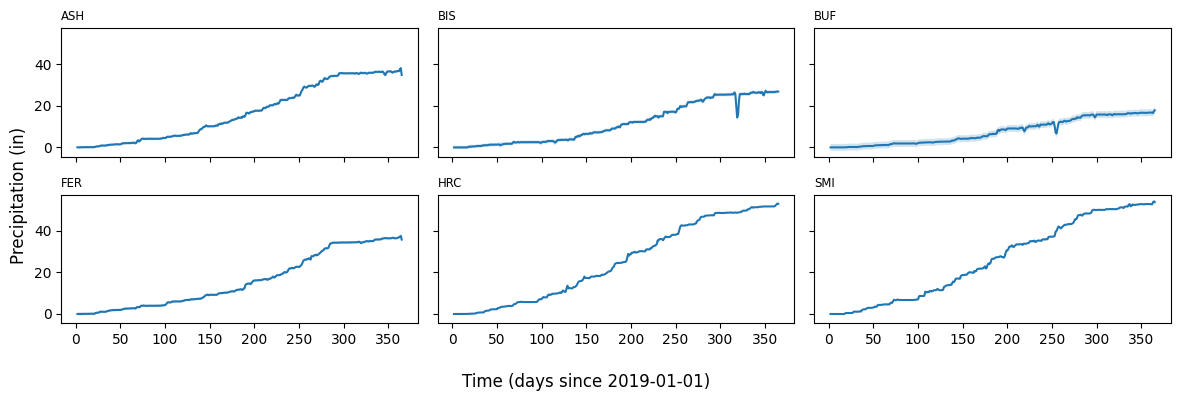

In [65]:
#predict data for vineyards
time_grid_doy = np.linspace(X_train[:, 2].min(), X_train[:, 2].max(), 364)

#cycle through sites to plot timeseries along with RMSE and R2
fig, ax = plt.subplots(2, 3, figsize=(12, 4), 
                       sharex = True, sharey = True, 
                       layout = 'tight')
axs = ax.ravel()
i = 0

for site in coords_sites.keys():
    fixed_lat = coords_sites[site]['lat']
    fixed_lon = coords_sites[site]['lon']
    
    # Create input grid: [fixed_lat, fixed_lon, time]
    X_time_grid_doy = np.stack([np.full_like(time_grid_doy, fixed_lat), np.full_like(time_grid_doy, fixed_lon), time_grid_doy], axis=1)
    
    # Predict temperatures over time
    y_pred_time_doy, y_std_time_doy = gpr.predict(X_time_grid_doy, return_std=True)
    
    axs[i].plot(time_grid_doy, y_pred_time_doy, label="Predicted Precip")
    axs[i].fill_between(time_grid_doy, y_pred_time_doy - 1.96*y_std_time_doy, y_pred_time_doy + 1.96*y_std_time_doy, alpha=0.2, label="95% CI")
    axs[i].set_title(site, size = 'small', loc = 'left')

    #save and export
    predicted_data = pd.DataFrame({'site' : site, 
                                  'doy' : time_grid_doy, 
                                  'lat' : fixed_lat, 
                                  'lon' : fixed_lon, 
                                  'variable' :'precip_cum',
                                  'value' : y_pred_time_doy})
    predicted_data.to_csv('./data/processed/' + site + '_precipIn_cumulative.csv', index = False)
    
    i = i+1

fig.supxlabel("Time (days since 2019-01-01)")
fig.supylabel("Precipitation (in)")
plt.savefig('./figures/climate interpolation/precipitation_predicted_vineyards.pdf', bbox_inches = 'tight')
plt.savefig('./figures/climate interpolation/precipitation_predicted_vinyeards.png', dpi = 300, bbox_inches = 'tight')
plt.show()